In [1]:
import torch 
import torch.nn as nn
import numpy as np
from core import *

from core.data_handler import *
from core.optimizer import *
from core.fit import *
from core.cbs import *
from core.evaluate import *
from models.Loss import *
import torch.distributions as torchdist
import matplotlib.pyplot as plt

from collections import OrderedDict

In [2]:
from torch.utils.data import BatchSampler,SequentialSampler

# Tools

In [3]:
class learner:
    def __init__(self):
        self.sched = None
        self.train_loss = None
        self.val_loss = None
        self.epoch = None
    def fit(self,model,opt,epoch,dl,crit,callbacks=[],metrics=[],**kwargs):
        '''Training module
        Inputs:
        ------
        model (nn model): model to be trained.
        opt (torch.optim): optmizer.
        dl : torch dataloader.
        crit: Loss function.
        callbacks: list of functions or callable classes to be run through certain steps.
        metrics: functions to be computed on results with ground truth.
        '''
        # on_epoch_begin
        for i in callbacks:
            i.on_epoch_begin(learn = self, model = model , opt = opt , crit = crit  ,dl = dl,**kwargs)

        for j in tnrange(epoch,desc="Epoch",position=1,mininterval=0):
            self.train_loss = 0
            self.val_loss = 0
            meters = []
            # on_train_begin
            for i in callbacks:
                i.on_train_begin(learn = self, model = model , opt = opt , crit = crit  ,dl = dl,**kwargs)


            t=tqdm(iter(dl.trn_dl), leave=False, total=len(dl.trn_dl), miniters=0 ,postfix = f'Loss: {self.train_loss}')
            model.train()
            self.epoch = 0
            for data in t:
                # on_train_batch_begin
                for i in callbacks:
                    i.on_train_batch_begin(learn = self,model = model , opt = opt , crit = crit ,dl = dl,**kwargs)

                self.epoch += 1
                t.close()
                t.set_postfix_str(f'loss : {float(self.train_loss)/self.epoch}',refresh = True)

                opt.zero_grad()

                data = data.cuda() if type(data) not in [list,tuple] else (i.cuda() for i in data)
                out = model(*data)

                loss = crit(out,data)
                loss.backward(retain_graph=True)
                opt.step()

                # on_train_batch_end
                self.train_loss += loss.data

                for i in callbacks:
                    i.on_train_batch_end(learn = self,model = model , opt = opt , crit = crit ,dl = dl,**kwargs)


            # on_val_begin
            for i in callbacks:
                i.on_val_begin(learn = self,model = model , opt = opt , crit = crit  ,dl = dl,**kwargs)

            self.epoch = 0
            with torch.no_grad():


                model.eval()
                t=tqdm(iter(dl.val_dl), leave=False, total=len(dl.val_dl), miniters=0,postfix = f'Loss: {self.val_loss}')
                for  data in t:
                    #on val_batch_begin
                    for i in callbacks:
                        i.on_val_batch_begin(learn = self,model = model , opt = opt , crit = crit  ,dl = dl,**kwargs)
                    self.epoch += 1

                    data = data.cuda() if type(data) not in [list,tuple] else [i.cuda() for i in data]
                    out = model(*data)

                    loss = crit(out,data)


                    #on val_batch_end
                    self.val_loss += loss.data
                    meters.append(calc_metrics(out,data,metrics))
                    for i in callbacks:
                        i.on_val_batch_end(learn = self,model = model , opt = opt , crit = crit  ,dl = dl,meters = meters,**kwargs)

                    t.close()
                    t.set_postfix_str(f'loss : {float(self.val_loss)/self.epoch}',refresh = True)
                
                
                
            
            # on_val_end
            
            for i in callbacks:
                i.on_val_end(learn=self , model = model , opt = opt , crit = crit  ,dl = dl,**kwargs)
            
            self.train_loss /= len(dl.trn_dl)
            self.val_loss /= len(dl.val_dl)
            model.record(self.val_loss)
            print('train Loss: ', self.train_loss.tolist(),'  validation loss: ',
                  self.val_loss.tolist())
            # Needs editing
            print(torch.tensor(meters).mean())
        #on epoch end
        for i in callbacks:
                i.on_epoch_end(learn=self ,model = model , opt = opt , crit = crit  ,dl = dl,meters = meters,**kwargs)

In [4]:
class Validate(Callbacks):
    '''Evaluate a Dataset after training ends
    '''
    def __init__(self,dl):
        self.dl = dl
        self.test_loss = []
        
        self.meter_loss = 0
    def on_epoch_end(self,**kwargs):
        model = kwargs.get('model',False)
        crit = kwargs.get('crit',False)
        
        self.test_loss = []
        with torch.no_grad():
            model.eval()
            t=tqdm(iter(self.dl), leave=False, total=len(self.dl), miniters=0)
            print('testing...')
    
            for data in t:
                if next(model.parameters()).is_cuda:
                    data = data.cuda() if type(data) not in [list,tuple] else [i.cuda() for i in data]
                out = model(*data)
                loss = crit(out,data)
                
                self.test_loss.append(loss)
                
                t.close()
    def evaluate(self,**kwargs):
        self.on_epoch_end(**kwargs)

In [5]:
def split(base_dir, prc=0.2 ,test_pcg = None ,dataset_pct = 1,**kwargs):
    '''
    Function: splits dataset to training and validation
    Input: 
    base_dir(str): path to the dataset
    prc(float) : ratio between validation set size and dataset size
    dataset_pct(float) :percentage of dataset to be used
    Output:
    train dataset
    Val dataset
    Example:
    
    split('dataset/binary dataset/',dataset_pct=0.12,dim = (1,112,112),  mode= 'center' ,word_type = torch.LongTensor)
    '''
    total_size = int(len(os.listdir(base_dir)) * dataset_pct)
    
    if test_pcg:
        
        val_size = int(total_size*prc)
        test_size = int(total_size*test_pcg)
        trn_index = np.arange(total_size - val_size - test_size)
        val_index = np.arange(trn_index[-1]+1,trn_index[-1]+ val_size +1 )
        test_index = np.arange(trn_index[-1]+ val_size +2,total_size )
        
            
    else:
        val_size = int(total_size*prc)
        trn_index = np.arange(total_size - val_size)
        val_index = np.arange(trn_index[-1]+1,total_size)
    
    
    trn = dataset(base_dir , trn_index,generation_type='train',**kwargs)
    val = dataset(base_dir , val_index,generation_type='eval',**kwargs)
    if test_pcg:
        
        test = dataset(base_dir , test_index,**kwargs)
        return trn,val,test
    return trn,val

In [6]:
class dataset(Dataset):
    '''
    Function: splits dataset to training and validation
    Input: 
    base_dir(str): path to the dataset
    mode(str):define the type of padding required (right,left) default is 'right'
    index(list): list of interger numbers that represent the indicies of the data from base dir.
    Output:
    torch Dataset
    '''
    def __init__(self,base_dir , index=None,**kwargs):
        super().__init__()
        a = lambda x: int(x[5:-4])
        self.word_type = kwargs.get('word_type', float)
        files = os.listdir(base_dir)
        files = sorted(files,key=a)
        
        index = range(len(files)) if index is None else index
        self.data = [base_dir+files[i] for i in index]
        
        generation_type = kwargs.get('generation_type','eval')
        print('generation_type',generation_type)
        self.lka=None
        self.randomize_lka(generation_type)
        
    def __getitem__(self, index):
        word = np.load(self.data[index])  
        word = torch.from_numpy(word)
        lka = self.lka[index]
        return torch.tensor([word,lka]).type(self.word_type)
        
    def __len__(self):
        return len(self.data)
    def randomize_lka(self,generation_type):
        lka = self.generate_lka(generation_type)
        self.lka = lka.repeat(20,1).T.reshape(-1)[:len(self.data)]
        
    def generate_lka(self,generation_type):
        ''' generate lka signal based on hard coded durations.
        Inputs:
        ------
        generation_type str: could be train eval ones zeros exp1-exp5
        '''
        if generation_type == 'train':
            str1 =torch.randint(0,2,(55,))
            steer1 = str1[-1].repeat(48)
            str2 = torch.randint(0,2,(12,))#31
            switch1 = torch.zeros(88)
            str3 = torch.randint(0,2,(13,))
            steer2 = str2[-1].repeat(42)

            trn_lka = torch.cat([str1,steer1,str2,switch1,str3,steer2]).type(torch.float)
            return trn_lka
        
        elif generation_type == 'eval':
            #SEQ_len * length of addded tensor
            repetition = (len(self.data) // (20*16))+1
            #return train of lka -> get the size from the length of the data
            return torch.clone(torch.cat([torch.zeros(8),torch.ones(8)])).repeat(repetition).type(torch.float)
        elif generation_type == 'ones':
            #SEQ_len * length of addded tensor
            repetition = (len(self.data) // (20*8))+1
            #return train of lka -> get the size from the length of the data
            return torch.clone(torch.cat([torch.ones(8)])).repeat(repetition).type(torch.float)
        elif generation_type == 'zeros':
            #SEQ_len * length of addded tensor
            repetition = (len(self.data) // (20*8))+1
            #return train of lka -> get the size from the length of the data
            return torch.clone(torch.cat([torch.zeros(8)])).repeat(repetition).type(torch.float)
        elif generation_type == 'exp1':
            repetition = (len(self.data) // 20)+1
            zeros = torch.zeros(16)
            ones = torch.ones(repetition-16)
            return torch.clone(torch.cat([zeros,ones])).type(torch.float)
        elif generation_type == 'exp2':
            repetition = (len(self.data) // 20)+1
            z1 = torch.zeros(16)#4
            o1 = torch.ones(8)#6
            z2 = torch.zeros(16)#10
            o2 = torch.ones(80)# 30
            z3 = torch.zeros(repetition-30)
            return torch.clone(torch.cat([z1,o1,z2,o2,z3])).type(torch.float)
        elif generation_type == 'exp3':
            repetition = (len(self.data) // 20)+1
            z1 = torch.zeros(40)#10
            o1 = torch.ones(40)#20
            z2 = torch.zeros(repetition-20)
            return torch.clone(torch.cat([z1,o1,z2])).type(torch.float)
        elif generation_type == 'exp4':
            repetition = (len(self.data) // 20)+1
            z1 = torch.zeros(80)#20
            o1 = torch.ones(repetition-20)
            return torch.clone(torch.cat([z1,o1])).type(torch.float)
        elif generation_type == 'exp5':
            repetition = (len(self.data) // 20)+1
            z1 = torch.zeros(120)#30
            o1 = torch.ones(repetition-20)
            return torch.clone(torch.cat([z1,o1])).type(torch.float)


In [7]:
class Sequence_dl:
    '''
    Class that returns an iterator over the desired dataset with the ability to achieve overlaps
    Some data will be repeated in the next mini-batch as desired
    if overlap is set to be 0 the sampler acts as a normal sequential sampler
    args:
    dataset:torch dataset object
    bs(int): batch size
    seq_len(int): indicates the length of the single example (length of words or packets)
    overlap(int): Defines the number of words to be repeated and it must be less than the seq_len
    dim(list):Indicates the dimension of a single example
    '''
    def __init__(self,dataset,bs,seq_len, overlap ,dim=[112,112],drop_last=True,num_workers=4,generation_type='eval'):
        assert type(dim) == list , 'dim must be a list'
        self.dim = [bs,seq_len]
        self.dim.extend(dim)
        self.bs = bs
        self.seq_len = seq_len
        sam = BatchSampler(SequentialSampler(range(len(dataset))), batch_size=seq_len*bs, drop_last=drop_last)
        self.dl = DataLoader(dataset, batch_sampler=sam,num_workers=num_workers,collate_fn=self.helper)
    def helper(self,x):
        x = torch.stack(x).view(self.dim)
        x,lka = x[:,:,0],x[:,:,1]
        lka = lka.mean(dim=1)
        return x,lka
        #return torch.tensor(x).view(self.bs,self.seq_len)
    def __call__(self):
        return self.dl
    def __len__(self):
        return self.dl.__len__()
    def __iter__(self):
        return iter(self.dl)

In [8]:
class Random_LKA(Callbacks):
    def __init__(self,dataset,generation_type='train'):
        self.ds = dataset
        self.generation_type = generation_type
    def on_train_batch_end(self,**kwargs):
        '''on the end of training loop'''
        self.ds.randomize_lka(self.generation_type)

# Data

In [9]:
bs = 4
seq_len = 20
overlap=0

In [10]:
trn , val = split('../../dataset/fuz attack/generated_ds/v2/train/',prc = 0.2, dataset_pct=  1, dim =(2), word_type=torch.float)
atk  = LKADataset('../../dataset/fuz attack/generated_ds/amr/test/', dim = (2), word_type=torch.float,generation_type='eval')

generation_type train
generation_type eval
generation_type eval


In [11]:
trn_dl = Sequence_dl( trn, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[2],generation_type='train')
val_dl = Sequence_dl( val, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[2])
anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[2])

In [12]:
dl =CombineDataLoader(trn_dl,val_dl)

In [13]:
def iterator(dl):
    l=[]
    v=[]
    for i,j in dl:
        l.extend(i.mean(dim=1).data.numpy())
        v.extend(j.data.numpy())
        #l.extend(i[:,:,0].mean(dim=1).data.numpy())
        #v.extend(i[:,:,1].mean(dim=1).data.numpy())
    return l,v

In [7]:
t_rld,t_lka = iterator(trn_dl)
v_rld,v_lka = iterator(val_dl)
a_rld,a_lka = iterator(anml_dl)

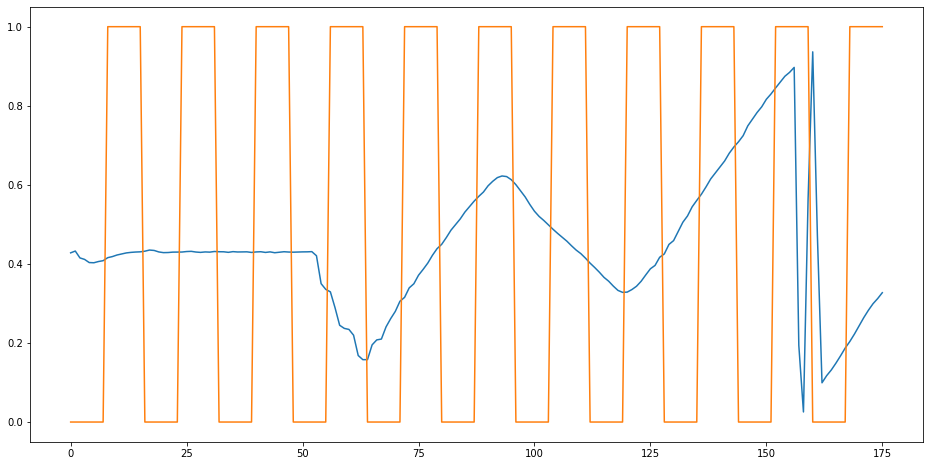

In [8]:
fig,ax=plt.subplots(figsize=(16,8))
plt.plot(a_rld)
plt.plot(a_lka)

Custom Loss

In [9]:
class mse:
    def __init__(self,enhncd,lam=0.5,reduction='mean'):
        self.enhncd,self.lam = enhncd,lam
        self.reduction=reduction
    def __call__(self,ip,tgt):
        if self.enhncd:
            tgt_lka,op_lka,(rcn_rld,tgt_rld) = ip
            rcn_loss = nn.functional.mse_loss(rcn_rld,tgt_rld)
            lka_loss = nn.functional.mse_loss(op_lka,tgt_lka)
            return self.lam*lka_loss + (1-self.lam)*rcn_loss
        #### LKA PART ####
        tgt_lka,op_lka = ip        
        lka_loss = nn.functional.binary_cross_entropy(op_lka,tgt_lka.squeeze(),reduction=self.reduction)
        return (lka_loss)

## Model

In [11]:
class LKAPredictor(BaseModel):    
    def __init__(self,bs,seq_len,rcn_w = 10,compress_hs=10,pred_hs=128,dp=0.4,enhncd=True):
        super().__init__()
        
        self.bs,self.seq_len,self.enhncd = bs,seq_len,enhncd
        
        self.lka_pred = nn.Sequential(nn.Linear(1+seq_len+compress_hs,pred_hs),
                                            nn.ReLU(),
                                            nn.Dropout(dp),
                                            nn.Linear(pred_hs,pred_hs),
                                            nn.ReLU(),
                                            nn.Dropout(dp),
                                            nn.Linear(pred_hs,1),
                                            nn.Sigmoid())
        
        self.rld_cmp = nn.Sequential(nn.Linear(seq_len+compress_hs,compress_hs),
                                            nn.PReLU())
        
        if enhncd:
            self.rld_rcn = nn.Sequential(nn.Linear(compress_hs,rcn_w))
        
        self.drop = nn.Dropout(dp)
        
        #### LKA - Training - RLD Variables ###
        self.lka,self.max_count,self.rcn_w  = None , 0,rcn_w
        self.register_buffer('p_lka',nn.Parameter(torch.zeros(self.bs,1).type(torch.float)))
        self.register_buffer('rld',nn.Parameter(torch.tensor([0.5]*compress_hs).repeat(self.bs).view(self.bs,-1)))
        #### Storage Elements####
        self.RLD_hist = []
        self.LKA_hist = []
    def forward(self,x,lka):
        device = 'cuda' if next(self.parameters()).is_cuda else 'cpu'
        x=x*4
        #########RLD COMPRESSION##########
        self.rld = self.rld_cmp(torch.cat([x.squeeze(dim=-1),self.rld],dim=-1))
        ########END OF RLD COMPRESSION####

        #Get the history of vis from previous vis and all the past frames
        x_drop = self.drop(x).squeeze(dim=-1)
        cat = torch.cat([self.p_lka,x_drop,self.rld],dim=-1)
        
        predicted_lka = self.lka_pred(cat).squeeze()
        
        #### Updates for LKA - RLD history - Minibatch counter ####
        self.rld = self.rld.detach()
        self.p_lka = lka.view(-1,1).detach().to(device)
        self.RLD_hist.extend(x.view(-1).detach().cpu().numpy())
        self.LKA_hist.extend(lka.view(-1).repeat(self.seq_len).detach().cpu().numpy())
        #### Reconstruction ####
        if self.enhncd:
            if len(self.RLD_hist) >= self.rcn_w*self.bs:
            
                rcn_rld = self.rld_rcn(self.rld)
                tgt_rld = torch.tensor(self.RLD_hist[-self.rcn_w*self.bs:]).view(self.bs,-1).clone().to(device)
            else:
                
                rcn_rld = self.rld_rcn(self.rld)[:,0:self.seq_len]
                tgt_rld = torch.tensor(self.RLD_hist).view(self.bs,self.seq_len).clone().to(device)
            return self.p_lka.squeeze(dim=-1),predicted_lka,(rcn_rld,tgt_rld)
        else:
            return self.p_lka,predicted_lka

In [9]:
from models.model import *

In [10]:
torch.manual_seed(1)

In [11]:
m = LKAPredictor(4,20,enhncd=False,rcn_w=5,pred_hs=512,dp=0.6,compress_hs=10).cuda()

In [12]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [13]:
trn_item = Validate(trn_dl)
val_item = Validate(val_dl)
anml_item = Validate(anml_dl)

In [14]:
RLKA = Random_LKA(trn)

In [15]:
loss = mse_bce_loss(enhncd=m.enhncd)

In [16]:
learn.fit(m , opt , 4 , dl,loss  ,callbacks=[RLKA])

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

train Loss:  0.81219881772995   validation loss:  0.7063544392585754
tensor(nan)


train Loss:  0.552993893623352   validation loss:  0.8171369433403015
tensor(nan)


train Loss:  0.9195330142974854   validation loss:  0.6987309455871582
tensor(nan)


train Loss:  0.8064219951629639   validation loss:  0.6959699988365173
tensor(nan)


In [17]:
anml_item.evaluate(model = m , crit = loss)

testing...


In [18]:
l = torch.stack(anml_item.test_loss).reshape(-1)

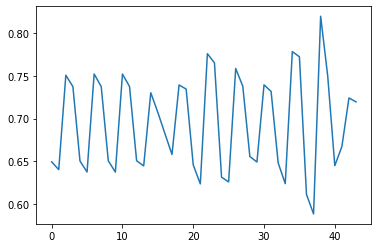

In [19]:
plt.plot(l.data.cpu().numpy())

In [20]:
res = []
for i in anml_dl:
    i = [j.cuda() for j in i]
    res.extend(m(*i)[1].view(-1).detach().cpu().numpy())

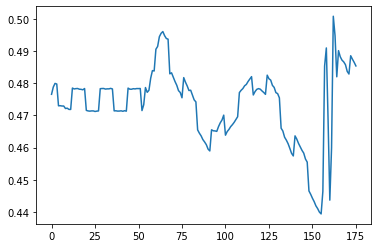

In [21]:
#plt.plot(res-t)
plt.plot(res)

In [136]:
#torch.save(m.cpu(),'./Models/نموذج واحد/basic/free_basic.pkl')

In [135]:
#torch.load('./Models/نموذج واحد/enhncd/enhncd.pkl')

# Model Evaluation

Get the plots of LKAs

In [31]:
torch.save(m,'./free_temp.pkl')

In [40]:
exp = ['zeros','ones','exp1','exp2','exp3','exp4','exp5','eval']
lka = []
rld=[]
for i in exp:
    atk  = dataset('../dataset/fuz attack/generated_ds/amr/test/', dim = (2), word_type=torch.float,generation_type=i)
    anml_dl = Sequence_dl( atk, bs=4,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[2])
    a_rld,a_lka = iterator(anml_dl)
    lka.append(a_lka)
    rld.append(a_rld)

generation_type zeros
generation_type ones
generation_type exp1
generation_type exp2
generation_type exp3
generation_type exp4
generation_type exp5
generation_type eval


In [41]:
len(rld[1])

176

In [33]:
res = []
loss.reduction = 'mean'
for i in exp:
    m = torch.load('./free_temp.pkl').cuda()
    atk  = dataset('../dataset/fuz attack/generated_ds/amr/test/', dim = (2), word_type=torch.float,generation_type=i)
    anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[2])
    anml_item = Validate(anml_dl)
    
    anml_item.evaluate(model = m , crit = loss)
    res.append(torch.stack(anml_item.test_loss).reshape(-1).cpu().numpy())

generation_type zeros


testing...


generation_type ones


testing...


generation_type exp1


...

testing...


generation_type exp5


testing...


generation_type eval


testing...


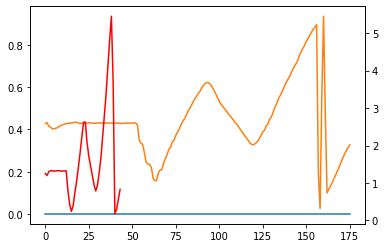

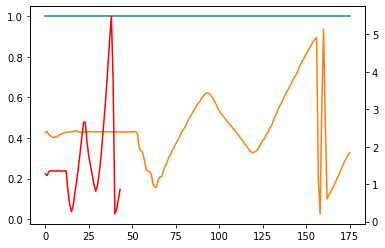

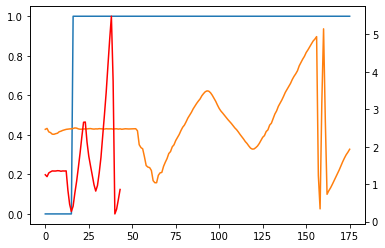

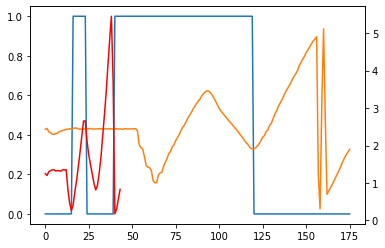

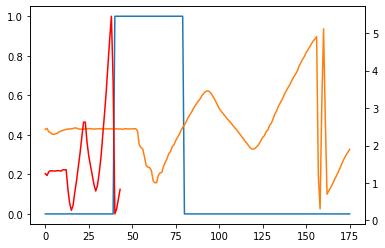

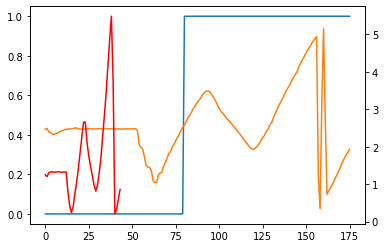

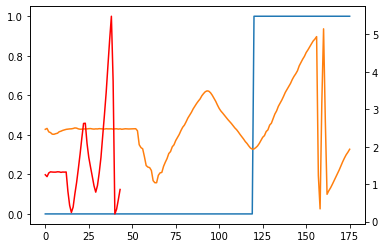

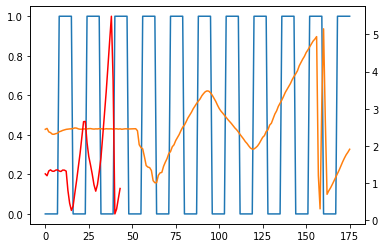

In [34]:
for i,name in enumerate(exp):
    fig,ax = plt.subplots()
    ax2 = ax.twinx()
    ax.plot(lka[i])
    ax.plot(a_rld)
    ax2.plot(res[i],label=name,c='r')

In [35]:
res[-1][::8][:7][1::8]

array([1.3271354], dtype=float32)

In [147]:
res[-1][::8][:7][1::2]

array([1.592946  , 2.468588  , 0.31905186], dtype=float32)

In [148]:
a,b = res[-1][::8][1::2] > 0.260 , res[-1][::8][1::2] < 0.264

In [243]:
a==b

array([False, False, False, False, False, False, False, False, False,
       False, False])

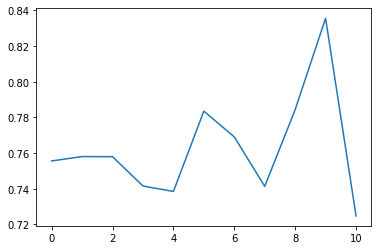

In [244]:
plt.plot(res[-1][0::8][1::2])
#plt.plot(lka[-1][::8])